**Experiment D**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 9.7 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 26.4M/26.4M [00:00<00:00, 109MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.34MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 50.4MB/s]


train: 60000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [
        perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
        for i in range(num_clients)
    ]

clients = build_iid_clients_from_indices(
    avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0
)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


In [5]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [6]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [7]:
# Cell 8 — Local client update
# Local client update (SGD) returns delta = (local - global)
# LF is interpreted as label flipping with cyclic shift y -> (y + 1) % NUM_CLASSES.

loss_fn = nn.CrossEntropyLoss()

def maybe_flip_labels(y, shift=1):
    return (y + int(shift)) % NUM_CLASSES

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  label_flip=False, label_flip_shift=1):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if label_flip:
                y = maybe_flip_labels(y, shift=label_flip_shift)

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())

    del local_model
    return delta

In [8]:
# Cell 9 — DP accounting (RDP) + sigma search
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.
# AG-PTR interpretation in this version:
#   - sigma_sel and sigma_rel are NOISE MULTIPLIERS
#   - add/remove adjacency
#   - selection sensitivity = 1
#   - release sensitivity = rho / m_hat <= rho / tau
#   - implementation adds noise AFTER normalization with std = sigma_rel * rho / m_hat

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(
            q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders
        )
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(
            orders=orders, rdp=rdp, delta=delta
        )
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sigma_sel = sel_factor * sigma_rel
    lo, hi = 1e-4, 1.0

    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor * sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

In [9]:
# Cell 10 — Attack helpers
# Byzantine attack helpers for:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Notes:
# - LF is implemented as label flipping and handled inside the train_* functions.
# - SF here is a sign-flip style update attack.
# - FoE here is an inner-product-manipulation / negative-mean style attack.

def normalize_attack_name(name):
    return str(name).strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def is_label_flip_attack(name):
    return normalize_attack_name(name) in {"lf", "labelflip", "labelflipping"}

@torch.no_grad()
def mean_update_list(update_list):
    if len(update_list) == 0:
        raise ValueError("No updates available.")
    P = len(update_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in update_list], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def _pairwise_sq_dists(X):
    gram = X @ X.t()
    diag = torch.diag(gram).unsqueeze(1)
    D = diag + diag.t() - 2.0 * gram
    return D.clamp_min(0.0)

@torch.no_grad()
def _deviation_vec(X):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False)

    dev = sd * torch.sign(mu)
    if torch.norm(dev) < 1e-12:
        dev = mu.clone()
    if torch.norm(dev) < 1e-12:
        dev = torch.ones_like(mu)

    dev = dev / (torch.norm(dev) + 1e-12)
    return mu, dev

def _search_lambda(valid_fn, hi_init=1.0, iters=40):
    lo, hi = 0.0, float(hi_init)

    while valid_fn(hi):
        lo = hi
        hi *= 2.0
        if hi > 1e6:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if valid_fn(mid):
            lo = mid
        else:
            hi = mid

    return float(lo)

@torch.no_grad()
def _attack_vec_alie(X, z=2.0, direction=-1.0):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    return mu + float(direction) * float(z) * sd

@torch.no_grad()
def _attack_vec_sf(X, scale=5.0):
    mu = X.mean(dim=0)
    mean_abs = X.abs().mean(dim=0) + 1e-12
    return -float(scale) * torch.sign(mu) * mean_abs

@torch.no_grad()
def _attack_vec_foe(X, scale=1.0):
    mu = X.mean(dim=0)
    return -float(scale) * mu

@torch.no_grad()
def _attack_vec_minmax(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.max().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def _attack_vec_minsum(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.sum(dim=1).max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.sum().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def build_byzantine_vecs_from_honest(honest_vecs, byz_count,
                                     attack_type="alie",
                                     alie_z=2.0, alie_direction=-1.0,
                                     sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest updates available to build this attack.")

    X = torch.stack(honest_vecs, dim=0)
    attack_key = normalize_attack_name(attack_type)

    if attack_key == "alie":
        mal = _attack_vec_alie(X, z=alie_z, direction=alie_direction)
    elif attack_key == "sf":
        mal = _attack_vec_sf(X, scale=sf_scale)
    elif attack_key == "minmax":
        mal = _attack_vec_minmax(X)
    elif attack_key == "minsum":
        mal = _attack_vec_minsum(X)
    elif attack_key in {"foe", "ipm", "fallofempires"}:
        mal = _attack_vec_foe(X, scale=foe_scale)
    elif is_label_flip_attack(attack_key):
        raise ValueError("LF is handled inside the training functions, not from honest updates.")
    else:
        raise ValueError(f"Unknown attack_type={attack_type!r}")

    mal = mal.detach()
    return [mal.clone() for _ in range(byz_count)]

@torch.no_grad()
def build_byzantine_updates_from_honest(honest_updates, byz_count,
                                        attack_type="alie",
                                        alie_z=2.0, alie_direction=-1.0,
                                        sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates available to build this attack.")

    template = honest_updates[0]
    honest_vecs = [flatten_list(u) for u in honest_updates]
    mal_vecs = build_byzantine_vecs_from_honest(
        honest_vecs, byz_count,
        attack_type=attack_type,
        alie_z=alie_z, alie_direction=alie_direction,
        sf_scale=sf_scale, foe_scale=foe_scale
    )

    out = []
    for v in mal_vecs:
        out.append([t.detach().clone() for t in unflatten_like(v, template)])
    return out

In [10]:
# Cell 11 — DP-FedAvg with selectable attacks + optional adaptive server step

def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack_type="alie",
                           alie_direction=-1.0, alie_z=2.0,
                           sf_scale=5.0, foe_scale=1.0,
                           label_flip_shift=1,
                           show_progress=True,
                           server_opt="sgd",          # "sgd" or "fedadam"
                           adam_eta=0.1,
                           adam_beta1=0.9,
                           adam_beta2=0.99,
                           adam_tau=1e-9,
                           adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    attack_key = normalize_attack_name(attack_type)
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"DP-FedAvg {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_client_ids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]

        apply_server_update_list_(
            model, avg_update,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

In [11]:
# Cell 12 — Geometry-aware AG-PTR + shared adaptive server helpers

# ------------------------------------------------------------
# Public-anchor helpers
# ------------------------------------------------------------
def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum,
                                   public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(int(pub_batch_size), len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=float(lr), momentum=float(momentum))

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())

    del local_model
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD run on it
      - anchor = pub_scale * delta_pub
    """
    rng = np.random.RandomState(int(seed))
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


# ------------------------------------------------------------
# Metric helpers for geometry P_t
# ------------------------------------------------------------
@torch.no_grad()
def norm_sq_list_metric(tlist, P_list=None):
    """
    ||x||_P^2 = sum_j <x_j, P_j x_j>, with diagonal P_j matching tensor shapes.
    If P_list is None, defaults to Euclidean norm.
    """
    if P_list is None:
        return norm_sq_list(tlist)
    s = None
    for t, w in zip(tlist, P_list):
        v = (w * t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12


@torch.no_grad()
def l2_norm_list_metric(tlist, P_list=None):
    return torch.sqrt(norm_sq_list_metric(tlist, P_list))


@torch.no_grad()
def dot_list_metric(a_list, b_list, P_list=None):
    """
    <a,b>_P = sum_j <a_j, P_j b_j>. If P_list is None, defaults to Euclidean.
    """
    if P_list is None:
        return dot_list(a_list, b_list)
    s = None
    for a, b, w in zip(a_list, b_list, P_list):
        v = (w * a * b).sum()
        s = v if s is None else s + v
    return s


# ------------------------------------------------------------
# FedAdam server step
# ------------------------------------------------------------
@torch.no_grad()
def fedadam_step_(model, m_state, v_state, delta_list,
                  eta=0.1, beta1=0.9, beta2=0.99, tau=1e-9, step_idx=0):
    """
    FedAdam server update:
      m <- beta1*m + (1-beta1)*delta
      v <- beta2*v + (1-beta2)*delta^2
      eta_t = eta * sqrt(1-beta2^(t+1)) / (1-beta1^(t+1))
      w <- w + eta_t * m / (sqrt(v) + tau)
    """
    b1 = float(beta1)
    b2 = float(beta2)

    for i, d in enumerate(delta_list):
        m_state[i].mul_(b1).add_(d, alpha=(1.0 - b1))
        v_state[i].mul_(b2).addcmul_(d, d, value=(1.0 - b2))

    eta_t = float(eta) * math.sqrt(1.0 - (b2 ** (step_idx + 1))) / (1.0 - (b1 ** (step_idx + 1)))

    for p, m, v in zip(model_param_list(model), m_state, v_state):
        p.data.add_(m / (torch.sqrt(v) + float(tau)), alpha=float(eta_t))


# ------------------------------------------------------------
# Shared server optimizer helpers for all methods
# ------------------------------------------------------------
@torch.no_grad()
def init_server_opt_state(model, server_opt="sgd", adam_v_init=1e-6):
    if server_opt == "sgd":
        return None
    if server_opt == "fedadam":
        return {
            "m_state": zero_like_params(model),
            "v_state": [torch.ones_like(p.data) * float(adam_v_init) for p in model_param_list(model)],
            "opt_step": 0,
        }
    raise ValueError("server_opt must be 'sgd' or 'fedadam'")


@torch.no_grad()
def apply_server_update_list_(model, update_list,
                              server_opt="sgd", opt_state=None,
                              adam_eta=0.1, adam_beta1=0.9, adam_beta2=0.99, adam_tau=1e-9):
    if server_opt == "sgd":
        add_update_(model, update_list, scale=1.0)
        return

    if server_opt == "fedadam":
        fedadam_step_(
            model,
            opt_state["m_state"],
            opt_state["v_state"],
            update_list,
            eta=adam_eta,
            beta1=adam_beta1,
            beta2=adam_beta2,
            tau=adam_tau,
            step_idx=opt_state["opt_step"],
        )
        opt_state["opt_step"] += 1
        return

    raise ValueError("server_opt must be 'sgd' or 'fedadam'")


@torch.no_grad()
def apply_server_update_flat_(model, flat_vec, template,
                              server_opt="sgd", opt_state=None,
                              adam_eta=0.1, adam_beta1=0.9, adam_beta2=0.99, adam_tau=1e-9):
    upd_list = unflatten_like(flat_vec.to(device), template)
    apply_server_update_list_(
        model, upd_list,
        server_opt=server_opt, opt_state=opt_state,
        adam_eta=adam_eta, adam_beta1=adam_beta1,
        adam_beta2=adam_beta2, adam_tau=adam_tau
    )


# ------------------------------------------------------------
# Geometry-aware AG-PTR
# ------------------------------------------------------------
def train_ag_ptr_geom(seed, eps_total, byz_frac,
                      sigma_sel, sigma_rel, delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      rho=0.4, tau=50,
                      R_pub_avg=16, pub_batch=40, pub_scale=0.12, public_epochs=2,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      allow_zero=False,
                      P_mode="identity",     # "identity" or "fedadam_diag"
                      adam_eta=0.1,
                      adam_beta1=0.9,
                      adam_beta2=0.99,
                      adam_tau=1e-9,
                      adam_v_init=1e-6,
                      show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)
    accept = 0

    attack_key = normalize_attack_name(attack_type)

    # FedAdam server state used in BOTH geometry variants
    m_state = zero_like_params(model)
    v_state = [torch.ones_like(p.data) * float(adam_v_init) for p in model_param_list(model)]
    opt_step = 0

    iterator = tqdm(
        range(rounds),
        desc=f"AG-PTR-Geom {str(attack_type).upper()} f={int(100*byz_frac)}% | P={P_mode}",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # Geometry P_t
        if P_mode == "identity":
            P_list = None
            inv_sqrtP_list = None
        elif P_mode == "fedadam_diag":
            denom_list = [(torch.sqrt(v).detach() + float(adam_tau)) for v in v_state]
            P_list = [1.0 / (d * d) for d in denom_list]   # P_t
            inv_sqrtP_list = denom_list                    # P_t^{-1/2}
        else:
            raise ValueError("P_mode must be 'identity' or 'fedadam_diag'")

        # Public anchor
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list_metric(a_pub, P_list).item())

        # Honest / Byzantine updates
        honest_updates, honest_slots = [], []
        byz_client_ids, byz_slots = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # Assign each client to nearest anchor in metric P_t
        n_pub = 0
        assign = []   # 0 = public anchor, 1 = zero anchor

        for dlt in deltas:
            d0 = float(norm_sq_list_metric(dlt, P_list).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list_metric(dlt, a_pub, P_list).item())

            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # DP noisy counts
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # Clip in metric P_t
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue

            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list_metric(offset, P_list).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Normalize first, then add DP noise in mean space
        mean_offsets = [so / m_hat for so in sum_offsets]
        noise_std = (float(sigma_rel) * float(rho)) / float(m_hat)

        if inv_sqrtP_list is None:
            for j in range(len(mean_offsets)):
                mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)
        else:
            for j in range(len(mean_offsets)):
                mean_offsets[j].add_(
                    torch.randn_like(mean_offsets[j]) * noise_std * inv_sqrtP_list[j]
                )

        mean_update = [a + mo for a, mo in zip(a_star, mean_offsets)]

        # Same FedAdam server optimizer in BOTH geometry variants
        fedadam_step_(
            model, m_state, v_state, mean_update,
            eta=adam_eta,
            beta1=adam_beta1,
            beta2=adam_beta2,
            tau=adam_tau,
            step_idx=opt_step
        )
        opt_step += 1

    acc = evaluate(model, test_loader)
    accept_rate = accept / rounds

    del model, m_state, v_state
    cleanup_cuda()
    return acc, accept_rate


# Backward-compatible alias
train_ag_ptr = train_ag_ptr_geom

In [12]:
# Cell 13 — FedVRDP with selectable attacks + optional adaptive server step

@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask


def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True,
                         server_opt="sgd",          # "sgd" or "fedadam"
                         adam_eta=0.1,
                         adam_beta1=0.9,
                         adam_beta2=0.99,
                         adam_tau=1e-9,
                         adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)
    attack_key = normalize_attack_name(attack_type)
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        apply_server_update_flat_(
            model, avg_vec, template,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

        mask = topk_mask_from_vec(avg_vec.detach(), k)

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

In [13]:
# Cell 13.1 — Robust baseline helpers
# Helpers used by Median / Trimmed Mean / Krum / SparseFed-style baselines.

def build_round_updates(model, rng, byz_frac, lr_t, momentum,
                        local_epochs=1, batch_size=10,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1):
    """
    Build the full list of client updates for one round, including honest and Byzantine clients.
    Returns:
        updates: list length CLIENTS_PER_ROUND, each entry is a list-of-tensors update
        byz_count: integer number of Byzantine clients in this round
    """
    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

    b = int(round(byz_frac * clients_per_round))
    byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

    honest_updates, honest_slots = [], []
    byz_client_ids, byz_slots = [], []

    attack_key = normalize_attack_name(attack_type)

    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_client_ids.append(cid)
            byz_slots.append(j)
            continue

        honest_updates.append(
            client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
        )
        honest_slots.append(j)

    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size,
                    label_flip=True, label_flip_shift=label_flip_shift
                )
                for cid in byz_client_ids
            ]
        else:
            byz_updates = build_byzantine_updates_from_honest(
                honest_updates, b,
                attack_type=attack_key,
                alie_z=alie_z, alie_direction=alie_direction,
                sf_scale=sf_scale, foe_scale=foe_scale
            )
    else:
        byz_updates = []

    updates = [None] * clients_per_round
    for upd, j in zip(honest_updates, honest_slots):
        updates[j] = upd
    for upd, j in zip(byz_updates, byz_slots):
        updates[j] = upd

    return updates, b


@torch.no_grad()
def stack_updates_cpu(update_list):
    """
    Convert a list of list-of-tensors updates into an [n_clients, d] CPU tensor.
    """
    return torch.stack(
        [flatten_list(upd).detach().cpu() for upd in update_list],
        dim=0
    )


@torch.no_grad()
def clip_flat_vec(vec, clip_C):
    nrm = torch.norm(vec) + 1e-12
    return vec * min(1.0, float(clip_C) / float(nrm))


@torch.no_grad()
def apply_flat_update_(model, flat_vec_cpu):
    """
    Apply a flattened update vector (stored on CPU) to the model.
    """
    template = zero_like_params(model)
    upd_list = unflatten_like(flat_vec_cpu.to(device), template)
    add_update_(model, upd_list, scale=1.0)


@torch.no_grad()
def coord_median_vec(mat):
    """
    Coordinate-wise median over rows of mat, shape [n, d].
    """
    return mat.median(dim=0).values


@torch.no_grad()
def trimmed_mean_vec(mat, trim_k):
    """
    Coordinate-wise trimmed mean over rows of mat, trimming trim_k smallest
    and trim_k largest values in each coordinate.
    """
    n = mat.size(0)
    trim_k = int(max(0, min(int(trim_k), (n - 1) // 2)))

    if trim_k == 0 or 2 * trim_k >= n:
        return mat.mean(dim=0)

    vals, _ = torch.sort(mat, dim=0)
    return vals[trim_k:n - trim_k].mean(dim=0)


@torch.no_grad()
def krum_select_vec(mat, byz_count):
    """
    Krum selection rule on flattened client updates.
    Score(i) = sum of squared distances to the n - f - 2 nearest neighbors.
    Returns the selected update vector.
    """
    n = mat.size(0)
    neighbor_count = max(1, min(n - 1, n - int(byz_count) - 2))

    sq = _pairwise_sq_dists(mat)

    scores = []
    for i in range(n):
        d = torch.cat([sq[i, :i], sq[i, i + 1:]])
        vals, _ = torch.topk(d, k=neighbor_count, largest=False)
        scores.append(vals.sum())

    scores = torch.stack(scores)
    idx = int(torch.argmin(scores).item())
    return mat[idx].clone()


@torch.no_grad()
def topk_sparsify_vec(vec, k):
    """
    Keep only the top-k coordinates (by magnitude).
    """
    d = vec.numel()
    k = min(int(k), d)

    out = torch.zeros_like(vec)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        out[idx] = vec[idx]
    return out

In [14]:
# Cell 13.2 — Median baseline + optional adaptive server step

def train_median_robust(seed, eps_total, byz_frac,
                        delta=1e-5,
                        rounds=30, local_epochs=10, batch_size=10,
                        lr0=0.125, lr_decay=0.99, momentum=0.5,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1,
                        show_progress=True,
                        server_opt="sgd",          # "sgd" or "fedadam"
                        adam_eta=0.1,
                        adam_beta1=0.9,
                        adam_beta2=0.99,
                        adam_tau=1e-9,
                        adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"Median {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = coord_median_vec(mat)

        apply_server_update_flat_(
            model, agg_vec, template,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

In [15]:
# Cell 13.3 — Trimmed Mean baseline + optional adaptive server step

def train_trimmedmean_robust(seed, eps_total, byz_frac,
                             delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             trim_k=None,   # if None, use the actual byzantine count b each round
                             attack_type="alie",
                             alie_direction=-1.0, alie_z=2.0,
                             sf_scale=5.0, foe_scale=1.0,
                             label_flip_shift=1,
                             show_progress=True,
                             server_opt="sgd",          # "sgd" or "fedadam"
                             adam_eta=0.1,
                             adam_beta1=0.9,
                             adam_beta2=0.99,
                             adam_tau=1e-9,
                             adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"TrimmedMean {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        trim_this_round = b if trim_k is None else int(trim_k)
        agg_vec = trimmed_mean_vec(mat, trim_this_round)

        apply_server_update_flat_(
            model, agg_vec, template,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

In [16]:
# Cell 13.4 — Krum baseline + optional adaptive server step

def train_krum_robust(seed, eps_total, byz_frac,
                      delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      show_progress=True,
                      server_opt="sgd",          # "sgd" or "fedadam"
                      adam_eta=0.1,
                      adam_beta1=0.9,
                      adam_beta2=0.99,
                      adam_tau=1e-9,
                      adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"Krum {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = krum_select_vec(mat, b)

        apply_server_update_flat_(
            model, agg_vec, template,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

In [17]:
# Cell 13.5 — SparseFed-style baseline + optional adaptive server step

def train_sparsefed_style_robust(seed, eps_total, byz_frac,
                                 delta=1e-5,
                                 rounds=30, local_epochs=10, batch_size=10,
                                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                                 clip_C=1.0, k_frac=0.30,
                                 attack_type="alie",
                                 alie_direction=-1.0, alie_z=2.0,
                                 sf_scale=5.0, foe_scale=1.0,
                                 label_flip_shift=1,
                                 show_progress=True,
                                 server_opt="sgd",          # "sgd" or "fedadam"
                                 adam_eta=0.1,
                                 adam_beta1=0.9,
                                 adam_beta2=0.99,
                                 adam_tau=1e-9,
                                 adam_v_init=1e-6):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))
    opt_state = init_server_opt_state(model, server_opt=server_opt, adam_v_init=adam_v_init)

    iterator = tqdm(
        range(rounds),
        desc=f"SparseFed-style {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)

        clipped_rows = []
        for i in range(mat.size(0)):
            clipped_rows.append(clip_flat_vec(mat[i], clip_C))
        clipped_mat = torch.stack(clipped_rows, dim=0)

        avg_vec = clipped_mat.mean(dim=0)
        sparse_vec = topk_sparsify_vec(avg_vec, k)

        apply_server_update_flat_(
            model, sparse_vec, template,
            server_opt=server_opt, opt_state=opt_state,
            adam_eta=adam_eta, adam_beta1=adam_beta1,
            adam_beta2=adam_beta2, adam_tau=adam_tau
        )

    acc = evaluate(model, test_loader)
    del model, opt_state
    cleanup_cuda()
    return acc, 1.0

sigma_ag sel/rel: 1.6087871355020584 0.8043935677510292 achieved eps≈ 1.9999999999999973
Saved expD_geom_smoke_alie.csv


,attack,variant,f,acc,accept_rate
0,ALIE,AG-PTR (P=I),0.00,0.2496,1.0
1,ALIE,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,ALIE,AG-PTR (P=I),0.10,0.2764,1.0
3,ALIE,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,ALIE,AG-PTR (P=I),0.20,0.2864,1.0
5,ALIE,AG-PTR (FedAdam-diag P),0.20,0.4600,1.0
6,ALIE,AG-PTR (P=I),0.30,0.3670,1.0
7,ALIE,AG-PTR (FedAdam-diag P),0.30,0.4467,1.0
8,ALIE,AG-PTR (P=I),0.40,0.4089,1.0
9,ALIE,AG-PTR (FedAdam-diag P),0.40,0.4495,1.0


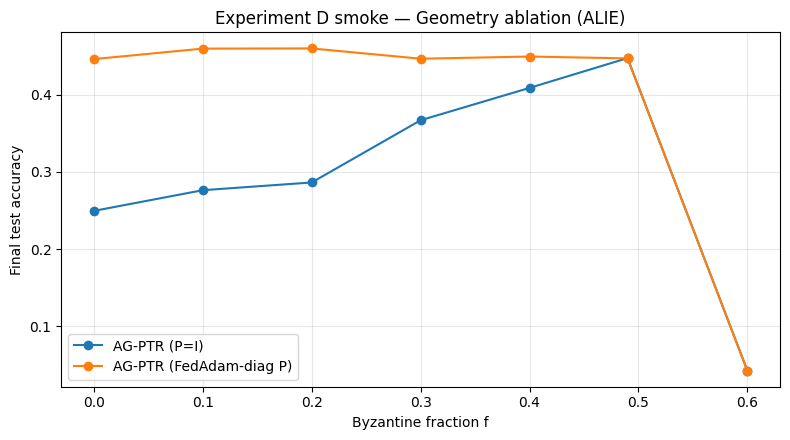

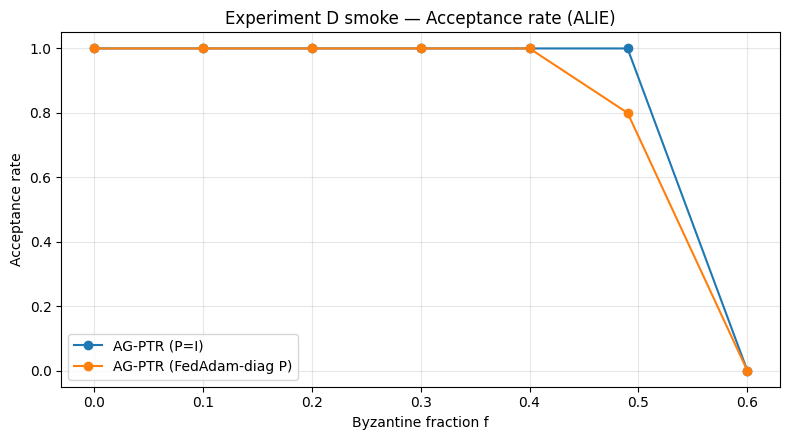

Saved expD_geom_smoke_sf.csv


,attack,variant,f,acc,accept_rate
0,SF,AG-PTR (P=I),0.00,0.2496,1.0
1,SF,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,SF,AG-PTR (P=I),0.10,0.1780,1.0
3,SF,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,SF,AG-PTR (P=I),0.20,0.2584,1.0
5,SF,AG-PTR (FedAdam-diag P),0.20,0.4602,1.0
6,SF,AG-PTR (P=I),0.30,0.2550,1.0
7,SF,AG-PTR (FedAdam-diag P),0.30,0.4471,1.0
8,SF,AG-PTR (P=I),0.40,0.3276,1.0
9,SF,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8


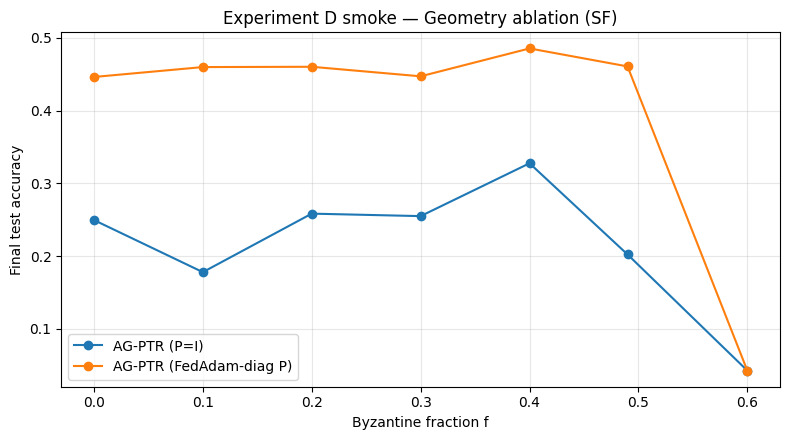

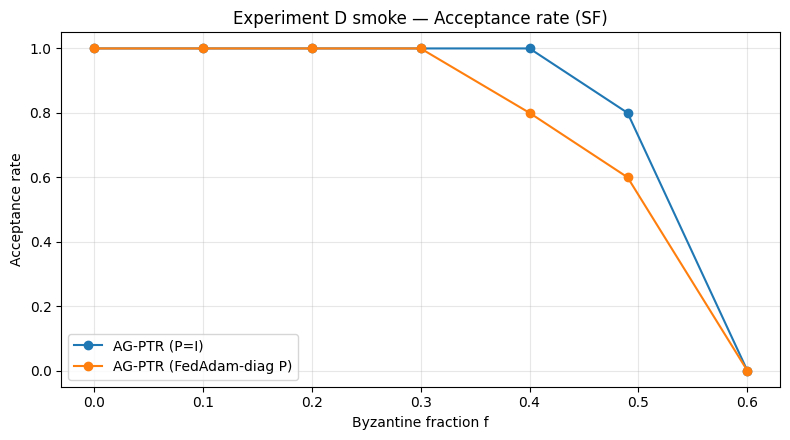

Saved expD_geom_smoke_minmax.csv


,attack,variant,f,acc,accept_rate
0,MinMax,AG-PTR (P=I),0.00,0.2496,1.0
1,MinMax,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,MinMax,AG-PTR (P=I),0.10,0.1625,1.0
3,MinMax,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,MinMax,AG-PTR (P=I),0.20,0.2656,1.0
5,MinMax,AG-PTR (FedAdam-diag P),0.20,0.4602,1.0
6,MinMax,AG-PTR (P=I),0.30,0.2550,1.0
7,MinMax,AG-PTR (FedAdam-diag P),0.30,0.4471,1.0
8,MinMax,AG-PTR (P=I),0.40,0.4080,1.0
9,MinMax,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8


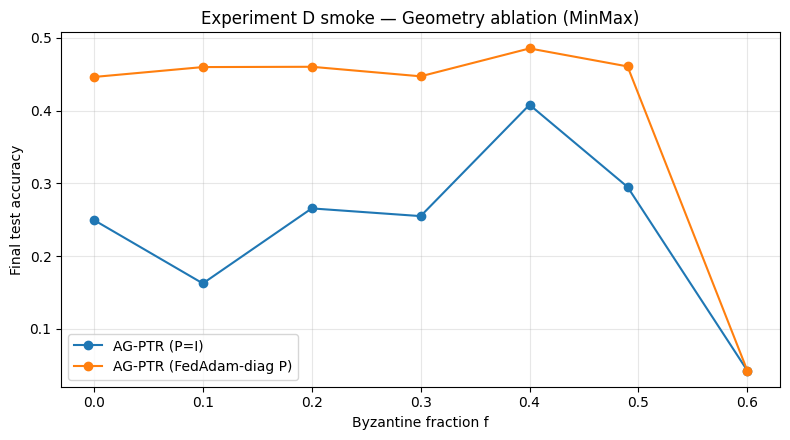

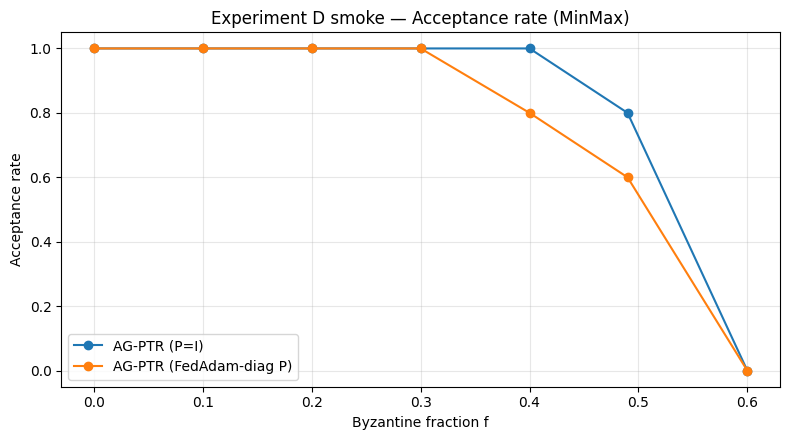

Saved expD_geom_smoke_minsum.csv


,attack,variant,f,acc,accept_rate
0,MinSum,AG-PTR (P=I),0.00,0.2496,1.0
1,MinSum,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,MinSum,AG-PTR (P=I),0.10,0.1616,1.0
3,MinSum,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,MinSum,AG-PTR (P=I),0.20,0.2584,1.0
5,MinSum,AG-PTR (FedAdam-diag P),0.20,0.4602,1.0
6,MinSum,AG-PTR (P=I),0.30,0.2550,1.0
7,MinSum,AG-PTR (FedAdam-diag P),0.30,0.4471,1.0
8,MinSum,AG-PTR (P=I),0.40,0.3836,1.0
9,MinSum,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8


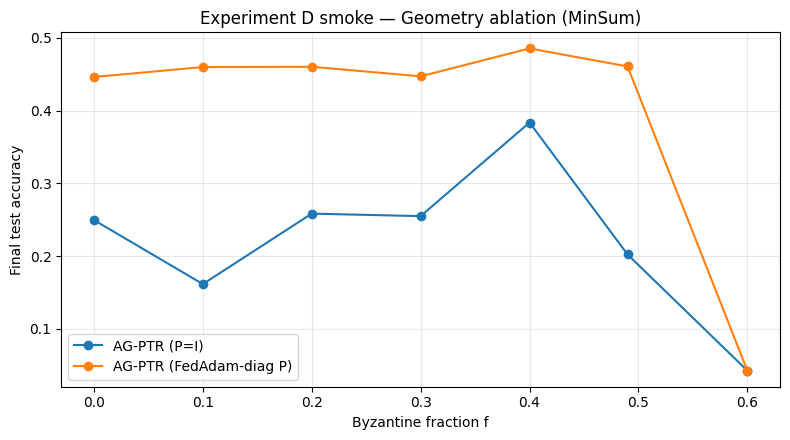

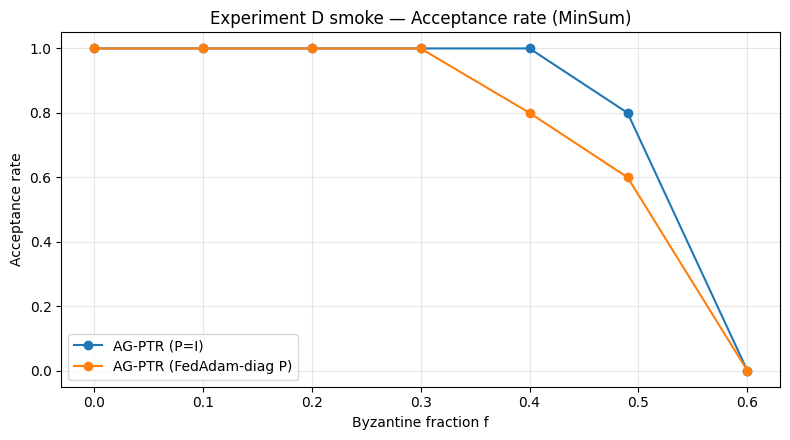

Saved expD_geom_smoke_lf.csv


,attack,variant,f,acc,accept_rate
0,LF,AG-PTR (P=I),0.00,0.2496,1.0
1,LF,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,LF,AG-PTR (P=I),0.10,0.2057,1.0
3,LF,AG-PTR (FedAdam-diag P),0.10,0.4599,1.0
4,LF,AG-PTR (P=I),0.20,0.1560,1.0
5,LF,AG-PTR (FedAdam-diag P),0.20,0.4546,1.0
6,LF,AG-PTR (P=I),0.30,0.2142,1.0
7,LF,AG-PTR (FedAdam-diag P),0.30,0.4490,1.0
8,LF,AG-PTR (P=I),0.40,0.1428,1.0
9,LF,AG-PTR (FedAdam-diag P),0.40,0.4496,1.0


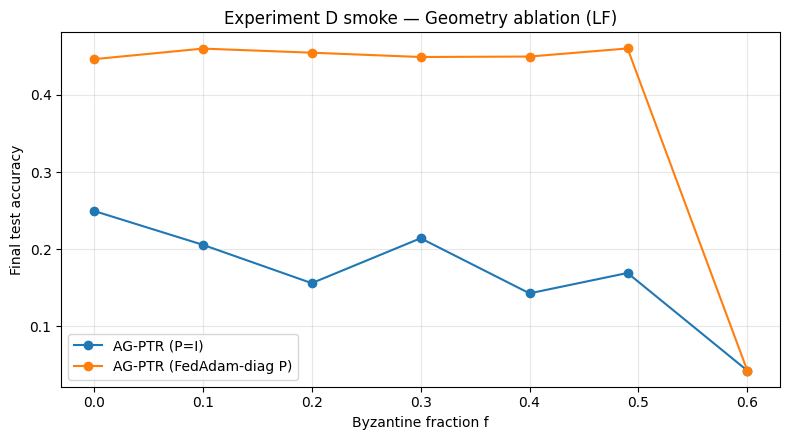

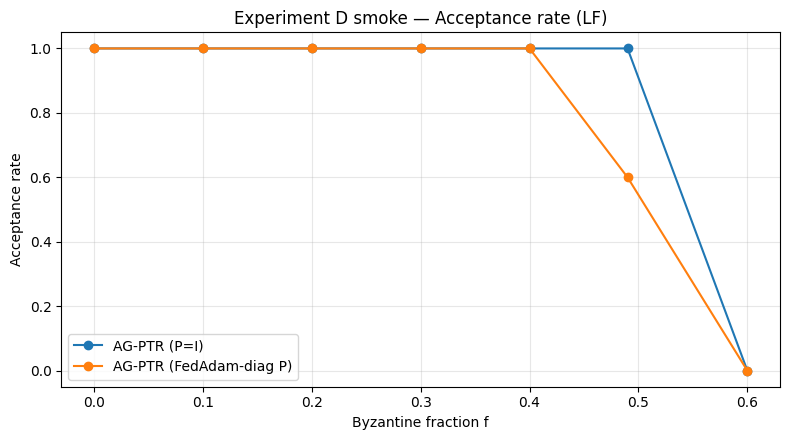

Saved expD_geom_smoke_foe.csv


,attack,variant,f,acc,accept_rate
0,FoE,AG-PTR (P=I),0.00,0.2496,1.0
1,FoE,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,FoE,AG-PTR (P=I),0.10,0.1780,1.0
3,FoE,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,FoE,AG-PTR (P=I),0.20,0.2584,1.0
5,FoE,AG-PTR (FedAdam-diag P),0.20,0.4602,1.0
6,FoE,AG-PTR (P=I),0.30,0.2550,1.0
7,FoE,AG-PTR (FedAdam-diag P),0.30,0.4471,1.0
8,FoE,AG-PTR (P=I),0.40,0.3276,1.0
9,FoE,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8


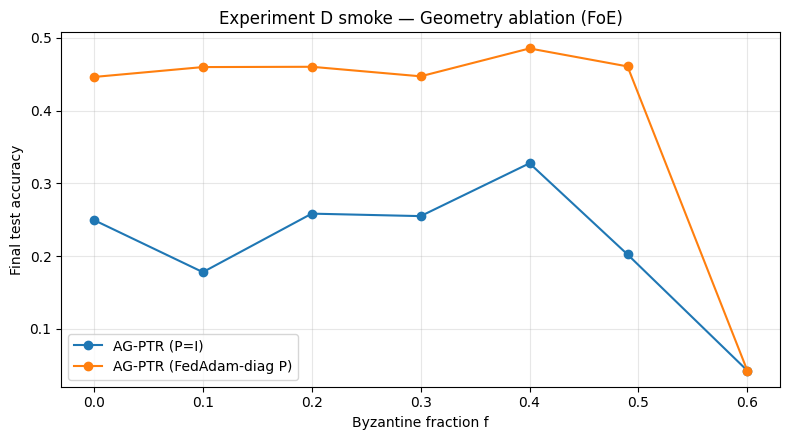

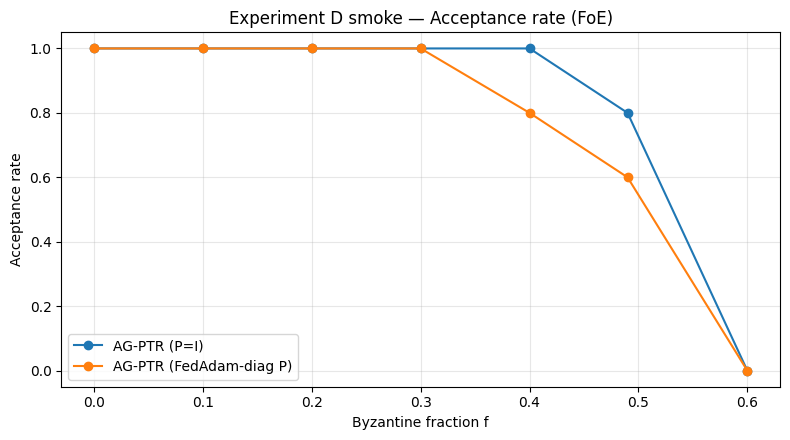

Saved expD_geom_smoke_all_results.csv


,attack,variant,f,acc,accept_rate
0,ALIE,AG-PTR (P=I),0.00,0.2496,1.0
1,ALIE,AG-PTR (FedAdam-diag P),0.00,0.4462,1.0
2,ALIE,AG-PTR (P=I),0.10,0.2764,1.0
3,ALIE,AG-PTR (FedAdam-diag P),0.10,0.4598,1.0
4,ALIE,AG-PTR (P=I),0.20,0.2864,1.0
...,...,...,...,...,...
79,FoE,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8
80,FoE,AG-PTR (P=I),0.49,0.2023,0.8
81,FoE,AG-PTR (FedAdam-diag P),0.49,0.4607,0.6
82,FoE,AG-PTR (P=I),0.60,0.0427,0.0


In [18]:
# Cell 14 — Smoke test 1: AG-PTR-only geometry ablation

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1

RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2

ADAM_ETA = 0.1
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
ADAM_TAU = 1e-9
ADAM_V_INIT = 1e-6

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

VARIANTS = [
    ("AG-PTR (P=I)", "identity"),
    ("AG-PTR (FedAdam-diag P)", "fedadam_diag"),
]

q = CLIENTS_PER_ROUND / len(clients)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)

all_rows = []

for attack_name, attack_key in ATTACKS:
    rows = []

    for f in f_list:
        for variant_name, p_mode in VARIANTS:
            acc, ar = train_ag_ptr_geom(
                seed, eps_total, f,
                sigma_sel, sigma_rel, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                rho=RHO, tau=TAU,
                R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                attack_type=attack_key,
                alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                label_flip_shift=LABEL_FLIP_SHIFT,
                allow_zero=False,
                P_mode=p_mode,
                adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1, adam_beta2=ADAM_BETA2,
                adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT,
                show_progress=False
            )

            rows.append({
                "attack": attack_name,
                "variant": variant_name,
                "f": f,
                "acc": acc,
                "accept_rate": ar
            })

    df_attack = pd.DataFrame(rows)
    df_attack.to_csv(f"expD_geom_smoke_{attack_key}.csv", index=False)
    print(f"Saved expD_geom_smoke_{attack_key}.csv")
    display(df_attack)

    plt.figure(figsize=(8, 4.5))
    for variant_name, _ in VARIANTS:
        sub = df_attack[df_attack["variant"] == variant_name]
        plt.plot(sub["f"], sub["acc"], marker="o", label=variant_name)
    plt.xlabel("Byzantine fraction f")
    plt.ylabel("Final test accuracy")
    plt.title(f"Experiment D smoke — Geometry ablation ({attack_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    for variant_name, _ in VARIANTS:
        sub = df_attack[df_attack["variant"] == variant_name]
        plt.plot(sub["f"], sub["accept_rate"], marker="o", label=variant_name)
    plt.xlabel("Byzantine fraction f")
    plt.ylabel("Acceptance rate")
    plt.title(f"Experiment D smoke — Acceptance rate ({attack_name})")
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    all_rows.extend(rows)

df_geom_smoke_all = pd.DataFrame(all_rows)
df_geom_smoke_all.to_csv("expD_geom_smoke_all_results.csv", index=False)
print("Saved expD_geom_smoke_all_results.csv")
display(df_geom_smoke_all)

sigma_dp: 0.804078106574686 achieved eps≈ 1.9999999999999978
sigma_ag sel/rel: 1.6087871355020584 0.8043935677510292 achieved eps≈ 1.9999999999999973
Baseline server optimizer: fedadam
FedAdam params: eta=0.1, beta1=0.9, beta2=0.99, tau=1e-09, v_init=1e-06

==================== Smoke Attack: ALIE ====================
Saved expD_allmethods_smoke_alie.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,ALIE,DP-FedAvg (FedAdam),0.10,0.0972,NaN
2,ALIE,DP-FedAvg (FedAdam),0.20,0.1590,NaN
3,ALIE,DP-FedAvg (FedAdam),0.30,0.2251,NaN
4,ALIE,DP-FedAvg (FedAdam),0.40,0.1690,NaN
5,ALIE,DP-FedAvg (FedAdam),0.49,0.1358,NaN
6,ALIE,DP-FedAvg (FedAdam),0.60,0.1391,NaN
7,ALIE,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,ALIE,FedVRDP-style (FedAdam),0.10,0.3968,NaN
9,ALIE,FedVRDP-style (FedAdam),0.20,0.5028,NaN


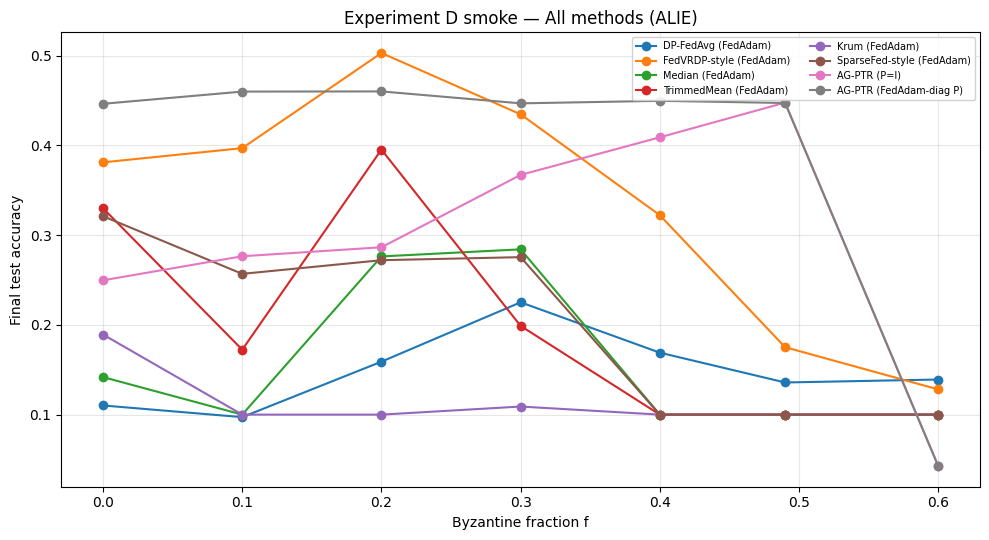

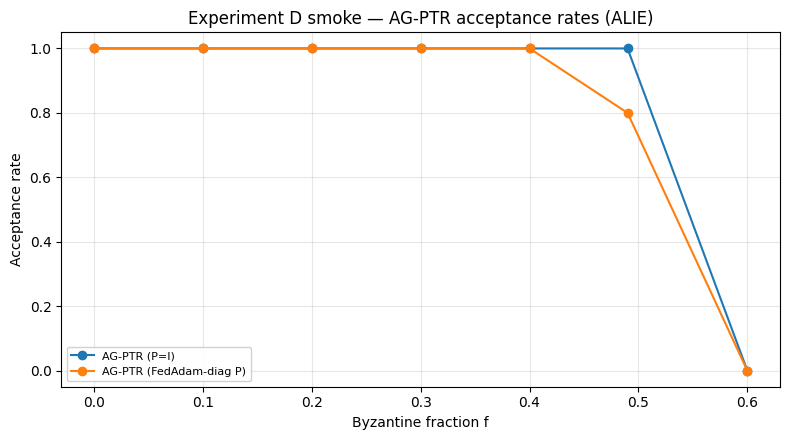


==================== Smoke Attack: SF ====================
Saved expD_allmethods_smoke_sf.csv


,attack,method,f,acc,accept_rate
0,SF,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,SF,DP-FedAvg (FedAdam),0.10,0.1242,NaN
2,SF,DP-FedAvg (FedAdam),0.20,0.2040,NaN
3,SF,DP-FedAvg (FedAdam),0.30,0.1293,NaN
4,SF,DP-FedAvg (FedAdam),0.40,0.1416,NaN
5,SF,DP-FedAvg (FedAdam),0.49,0.1000,NaN
6,SF,DP-FedAvg (FedAdam),0.60,0.1000,NaN
7,SF,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,SF,FedVRDP-style (FedAdam),0.10,0.3559,NaN
9,SF,FedVRDP-style (FedAdam),0.20,0.4385,NaN


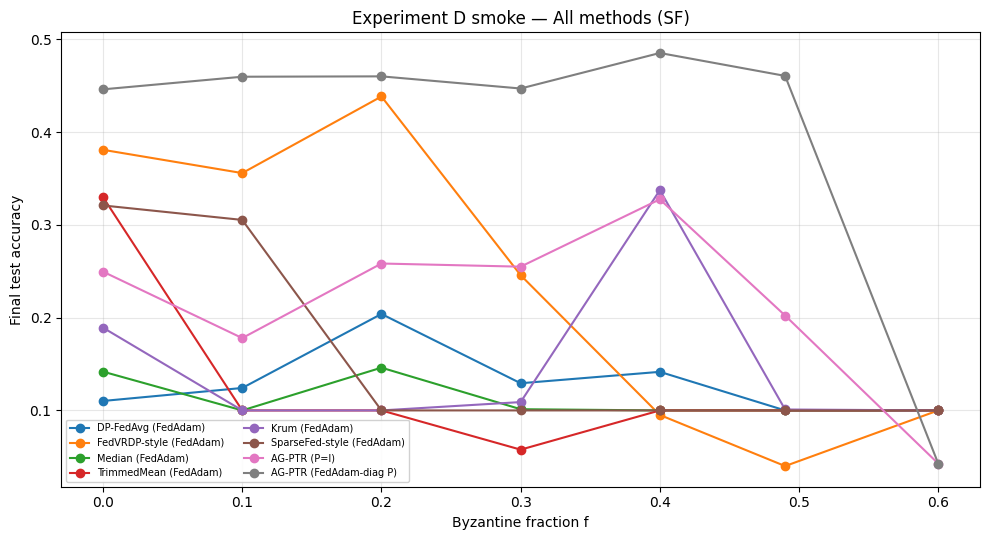

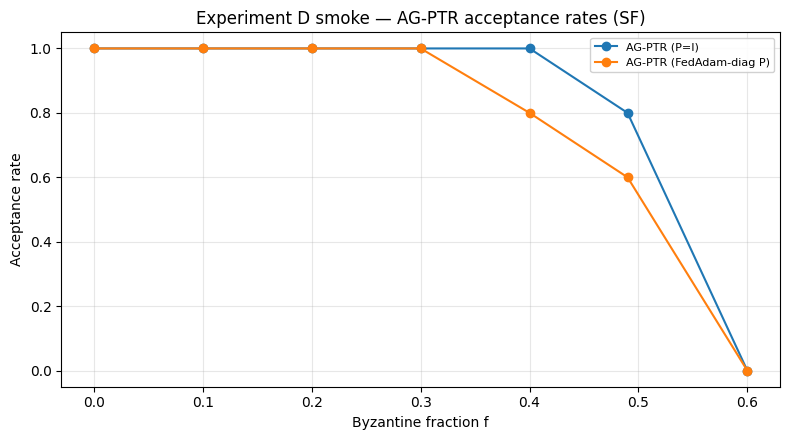


==================== Smoke Attack: MinMax ====================
Saved expD_allmethods_smoke_minmax.csv


,attack,method,f,acc,accept_rate
0,MinMax,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,MinMax,DP-FedAvg (FedAdam),0.10,0.1005,NaN
2,MinMax,DP-FedAvg (FedAdam),0.20,0.0848,NaN
3,MinMax,DP-FedAvg (FedAdam),0.30,0.1499,NaN
4,MinMax,DP-FedAvg (FedAdam),0.40,0.1010,NaN
5,MinMax,DP-FedAvg (FedAdam),0.49,0.1174,NaN
6,MinMax,DP-FedAvg (FedAdam),0.60,0.0999,NaN
7,MinMax,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,MinMax,FedVRDP-style (FedAdam),0.10,0.4827,NaN
9,MinMax,FedVRDP-style (FedAdam),0.20,0.2988,NaN


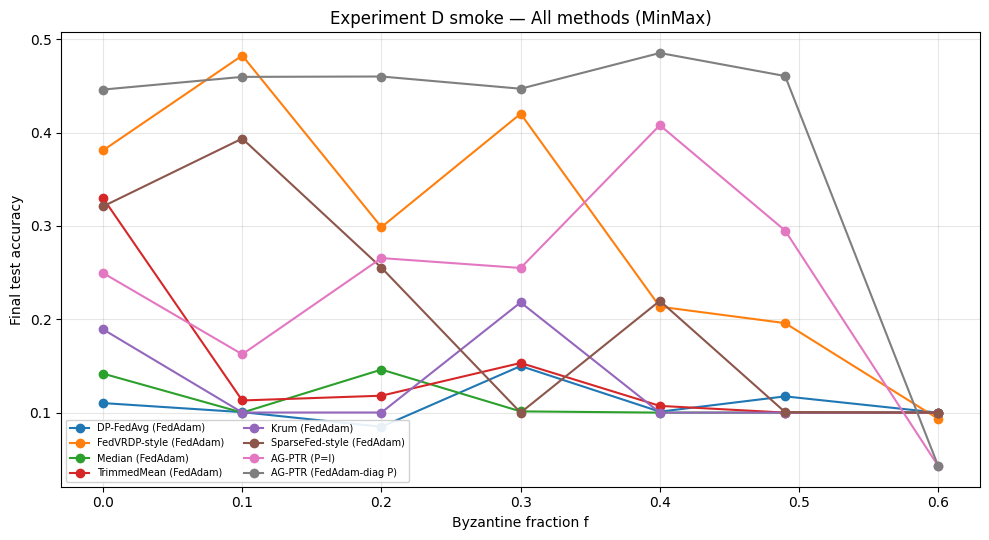

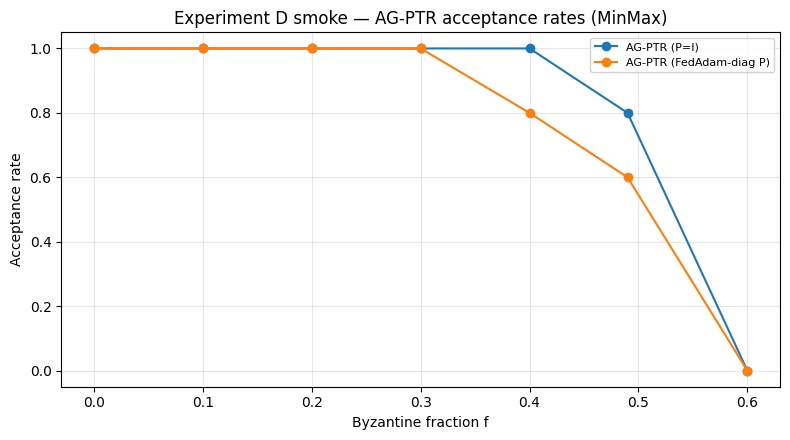


==================== Smoke Attack: MinSum ====================
Saved expD_allmethods_smoke_minsum.csv


,attack,method,f,acc,accept_rate
0,MinSum,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,MinSum,DP-FedAvg (FedAdam),0.10,0.0918,NaN
2,MinSum,DP-FedAvg (FedAdam),0.20,0.1695,NaN
3,MinSum,DP-FedAvg (FedAdam),0.30,0.1337,NaN
4,MinSum,DP-FedAvg (FedAdam),0.40,0.1697,NaN
5,MinSum,DP-FedAvg (FedAdam),0.49,0.1131,NaN
6,MinSum,DP-FedAvg (FedAdam),0.60,0.1074,NaN
7,MinSum,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,MinSum,FedVRDP-style (FedAdam),0.10,0.5150,NaN
9,MinSum,FedVRDP-style (FedAdam),0.20,0.2995,NaN


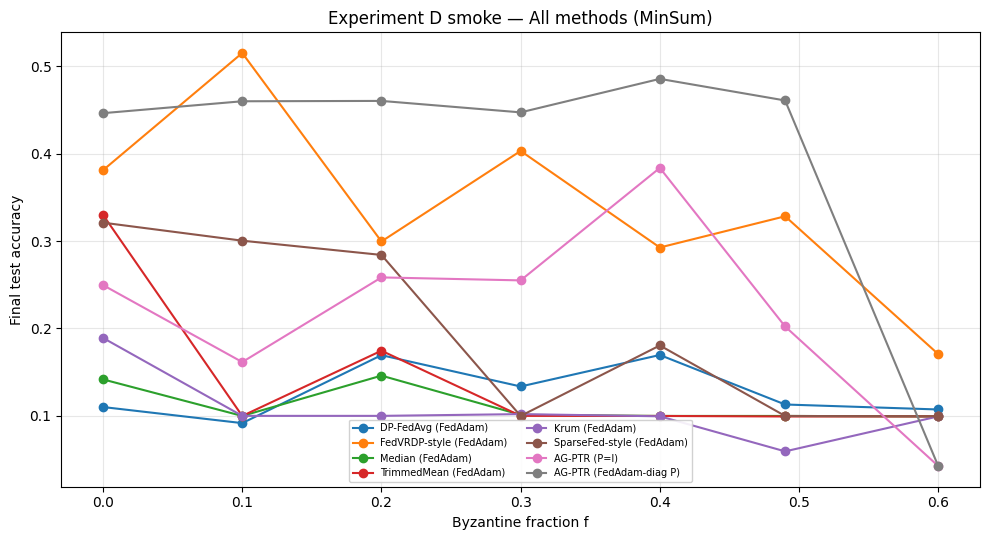

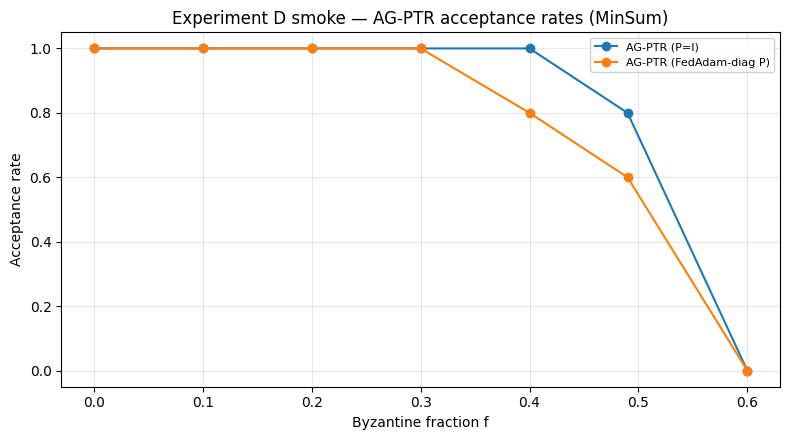


==================== Smoke Attack: LF ====================
Saved expD_allmethods_smoke_lf.csv


,attack,method,f,acc,accept_rate
0,LF,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,LF,DP-FedAvg (FedAdam),0.10,0.1181,NaN
2,LF,DP-FedAvg (FedAdam),0.20,0.1039,NaN
3,LF,DP-FedAvg (FedAdam),0.30,0.0904,NaN
4,LF,DP-FedAvg (FedAdam),0.40,0.0757,NaN
5,LF,DP-FedAvg (FedAdam),0.49,0.0769,NaN
6,LF,DP-FedAvg (FedAdam),0.60,0.0803,NaN
7,LF,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,LF,FedVRDP-style (FedAdam),0.10,0.3208,NaN
9,LF,FedVRDP-style (FedAdam),0.20,0.2599,NaN


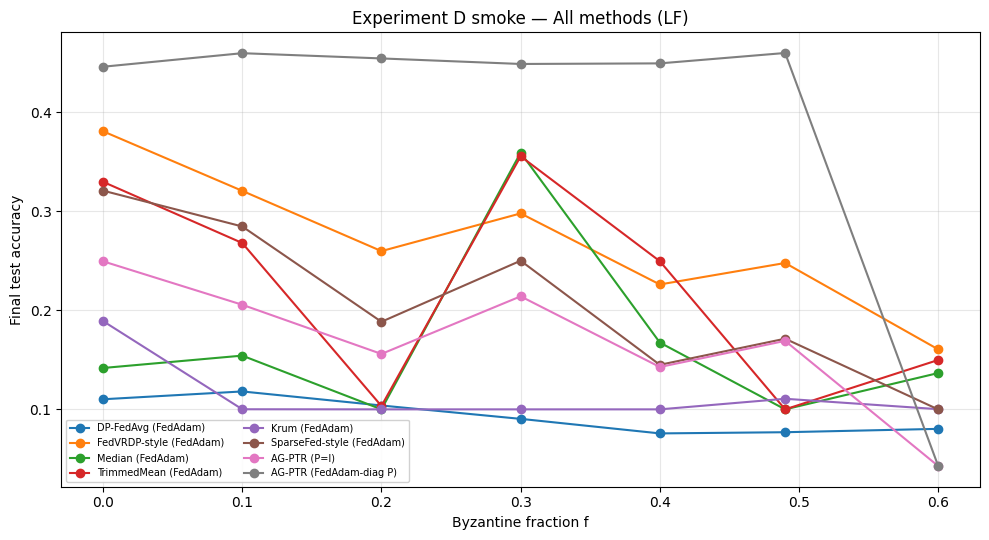

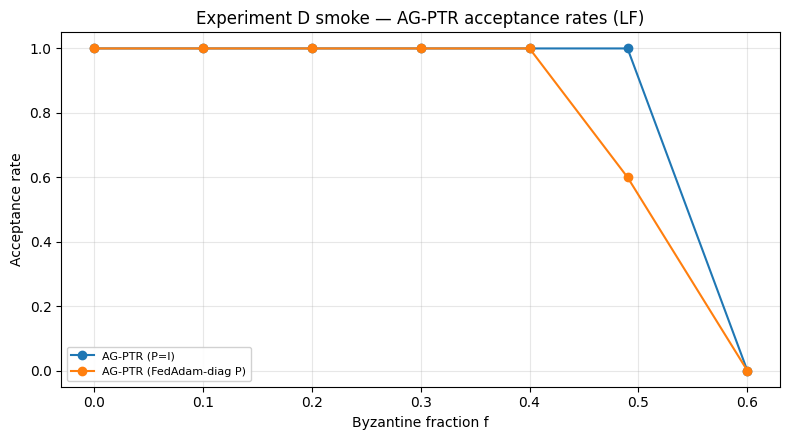


==================== Smoke Attack: FoE ====================
Saved expD_allmethods_smoke_foe.csv


,attack,method,f,acc,accept_rate
0,FoE,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,FoE,DP-FedAvg (FedAdam),0.10,0.1267,NaN
2,FoE,DP-FedAvg (FedAdam),0.20,0.1787,NaN
3,FoE,DP-FedAvg (FedAdam),0.30,0.2428,NaN
4,FoE,DP-FedAvg (FedAdam),0.40,0.2142,NaN
5,FoE,DP-FedAvg (FedAdam),0.49,0.1000,NaN
6,FoE,DP-FedAvg (FedAdam),0.60,0.1000,NaN
7,FoE,FedVRDP-style (FedAdam),0.00,0.3810,NaN
8,FoE,FedVRDP-style (FedAdam),0.10,0.3255,NaN
9,FoE,FedVRDP-style (FedAdam),0.20,0.3884,NaN


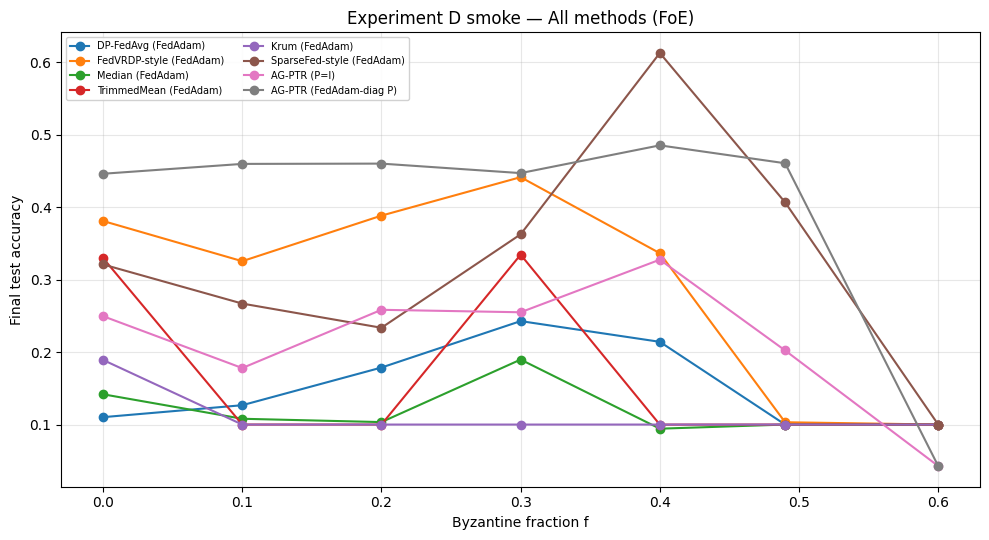

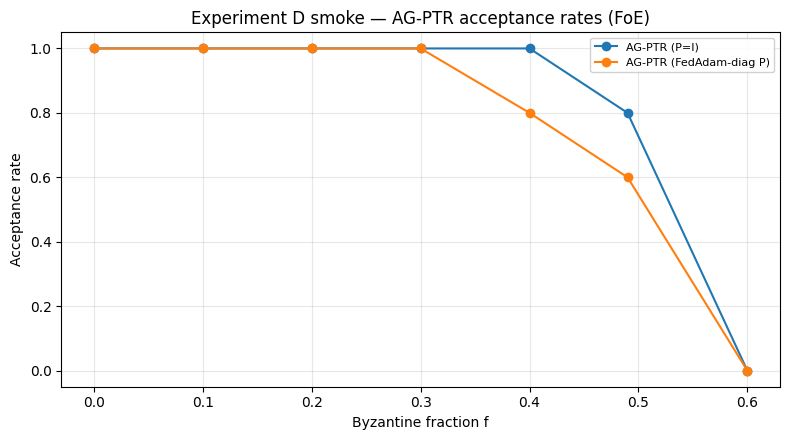

Saved expD_allmethods_smoke_all_results.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg (FedAdam),0.00,0.1102,NaN
1,ALIE,DP-FedAvg (FedAdam),0.10,0.0972,NaN
2,ALIE,DP-FedAvg (FedAdam),0.20,0.1590,NaN
3,ALIE,DP-FedAvg (FedAdam),0.30,0.2251,NaN
4,ALIE,DP-FedAvg (FedAdam),0.40,0.1690,NaN
...,...,...,...,...,...
331,SF,AG-PTR (FedAdam-diag P),0.20,0.4602,1.0
332,SF,AG-PTR (FedAdam-diag P),0.30,0.4471,1.0
333,SF,AG-PTR (FedAdam-diag P),0.40,0.4854,0.8
334,SF,AG-PTR (FedAdam-diag P),0.49,0.4607,0.6


In [19]:
# Cell 15 — Smoke test 2: all baselines + both AG-PTR variants

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

# Attack params
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1

# AG-PTR params
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2

# DP-FedAvg / FedVRDP-style params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30

# SparseFed-style params
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

# Shared FedAdam server params for baselines
BASELINE_SERVER_OPT = "fedadam"
ADAM_ETA = 0.1
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
ADAM_TAU = 1e-9
ADAM_V_INIT = 1e-6

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

AG_VARIANTS = [
    ("AG-PTR (P=I)", "identity"),
    ("AG-PTR (FedAdam-diag P)", "fedadam_diag"),
]

METHOD_ORDER = [
    "DP-FedAvg (FedAdam)",
    "FedVRDP-style (FedAdam)",
    "Median (FedAdam)",
    "TrimmedMean (FedAdam)",
    "Krum (FedAdam)",
    "SparseFed-style (FedAdam)",
    "AG-PTR (P=I)",
    "AG-PTR (FedAdam-diag P)",
]

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_dp = epsilon_from_sigma_single(sigma_dp, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("sigma_dp:", sigma_dp, "achieved eps≈", eps_dp)
print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"Baseline server optimizer: {BASELINE_SERVER_OPT}")
print(f"FedAdam params: eta={ADAM_ETA}, beta1={ADAM_BETA1}, beta2={ADAM_BETA2}, tau={ADAM_TAU}, v_init={ADAM_V_INIT}")

all_rows = []

for attack_name, attack_key in ATTACKS:
    print(f"\n==================== Smoke Attack: {attack_name} ====================")
    attack_rows = []

    for f in f_list:
        acc_dp, _ = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_vr, _ = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC_VR,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_med, _ = train_median_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_tmean, _ = train_trimmedmean_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            trim_k=None,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_krum, _ = train_krum_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_sparse, _ = train_sparsefed_style_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        attack_rows.extend([
            {"attack": attack_name, "method": "DP-FedAvg (FedAdam)",       "f": f, "acc": acc_dp,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "FedVRDP-style (FedAdam)",   "f": f, "acc": acc_vr,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "Median (FedAdam)",          "f": f, "acc": acc_med,    "accept_rate": np.nan},
            {"attack": attack_name, "method": "TrimmedMean (FedAdam)",     "f": f, "acc": acc_tmean,  "accept_rate": np.nan},
            {"attack": attack_name, "method": "Krum (FedAdam)",            "f": f, "acc": acc_krum,   "accept_rate": np.nan},
            {"attack": attack_name, "method": "SparseFed-style (FedAdam)", "f": f, "acc": acc_sparse, "accept_rate": np.nan},
        ])

        for ag_name, p_mode in AG_VARIANTS:
            acc_ag, ar_ag = train_ag_ptr_geom(
                seed, eps_total, f,
                sigma_sel, sigma_rel, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                rho=RHO, tau=TAU,
                R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                attack_type=attack_key,
                alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                label_flip_shift=LABEL_FLIP_SHIFT,
                allow_zero=False,
                P_mode=p_mode,
                adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
                adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT,
                show_progress=False
            )

            attack_rows.append({
                "attack": attack_name,
                "method": ag_name,
                "f": f,
                "acc": acc_ag,
                "accept_rate": ar_ag
            })

    df_attack = pd.DataFrame(attack_rows)
    df_attack["method"] = pd.Categorical(df_attack["method"], categories=METHOD_ORDER, ordered=True)
    df_attack = df_attack.sort_values(["method", "f"]).reset_index(drop=True)

    df_attack.to_csv(f"expD_allmethods_smoke_{attack_key}.csv", index=False)
    print(f"Saved expD_allmethods_smoke_{attack_key}.csv")
    display(df_attack)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for method in METHOD_ORDER:
        sub = df_attack[df_attack["method"] == method]
        ax.plot(sub["f"], sub["acc"], marker="o", label=method)
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Final test accuracy")
    ax.set_title(f"Experiment D smoke — All methods ({attack_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9, ncol=2)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    sub = df_attack[df_attack["method"].isin(["AG-PTR (P=I)", "AG-PTR (FedAdam-diag P)"])]
    for method in ["AG-PTR (P=I)", "AG-PTR (FedAdam-diag P)"]:
        ss = sub[sub["method"] == method]
        ax.plot(ss["f"], ss["accept_rate"], marker="o", label=method)
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Acceptance rate")
    ax.set_title(f"Experiment D smoke — AG-PTR acceptance rates ({attack_name})")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
    fig.tight_layout()
    plt.show()

    all_rows.extend(attack_rows)

df_smoke_all = pd.DataFrame(all_rows)
df_smoke_all["method"] = pd.Categorical(df_smoke_all["method"], categories=METHOD_ORDER, ordered=True)
df_smoke_all = df_smoke_all.sort_values(["attack", "method", "f"]).reset_index(drop=True)

df_smoke_all.to_csv("expD_allmethods_smoke_all_results.csv", index=False)
print("Saved expD_allmethods_smoke_all_results.csv")
display(df_smoke_all)

sigma_dp: 0.9723217465539842 achieved eps≈ 1.9999999999999973
sigma_ag sel/rel: 1.965902445173369 0.9829512225866845 achieved eps≈ 1.999999999999998
Baseline server optimizer: fedadam
FedAdam params: eta=0.1, beta1=0.9, beta2=0.99, tau=1e-09, v_init=1e-06

==================== Smoke Attack: ALIE ====================
Saved expD_allmethods_smoke_alie.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,ALIE,DP-FedAvg (FedAdam),0.10,0.1023,NaN
2,ALIE,DP-FedAvg (FedAdam),0.20,0.1026,NaN
3,ALIE,DP-FedAvg (FedAdam),0.30,0.1273,NaN
4,ALIE,DP-FedAvg (FedAdam),0.40,0.1013,NaN
5,ALIE,DP-FedAvg (FedAdam),0.49,0.1007,NaN
6,ALIE,DP-FedAvg (FedAdam),0.60,0.1007,NaN
7,ALIE,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,ALIE,FedVRDP-style (FedAdam),0.10,0.3685,NaN
9,ALIE,FedVRDP-style (FedAdam),0.20,0.1405,NaN


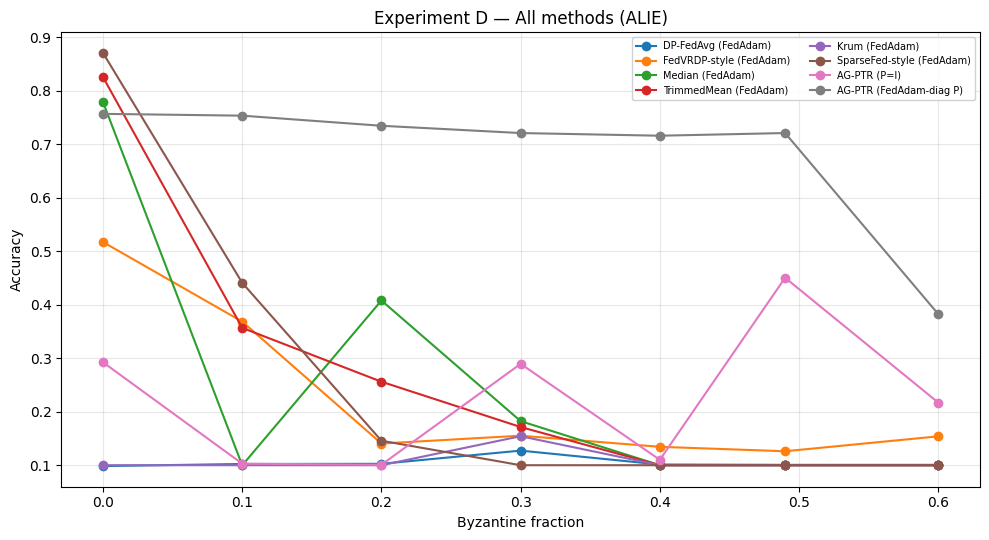

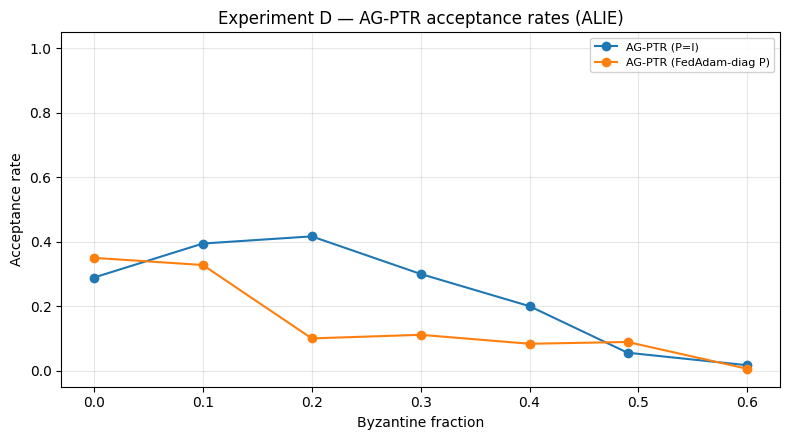


==================== Smoke Attack: SF ====================
Saved expD_allmethods_smoke_sf.csv


,attack,method,f,acc,accept_rate
0,SF,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,SF,DP-FedAvg (FedAdam),0.10,0.1172,NaN
2,SF,DP-FedAvg (FedAdam),0.20,0.4761,NaN
3,SF,DP-FedAvg (FedAdam),0.30,0.4189,NaN
4,SF,DP-FedAvg (FedAdam),0.40,0.2319,NaN
5,SF,DP-FedAvg (FedAdam),0.49,0.1000,NaN
6,SF,DP-FedAvg (FedAdam),0.60,0.1000,NaN
7,SF,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,SF,FedVRDP-style (FedAdam),0.10,0.5740,NaN
9,SF,FedVRDP-style (FedAdam),0.20,0.4869,NaN


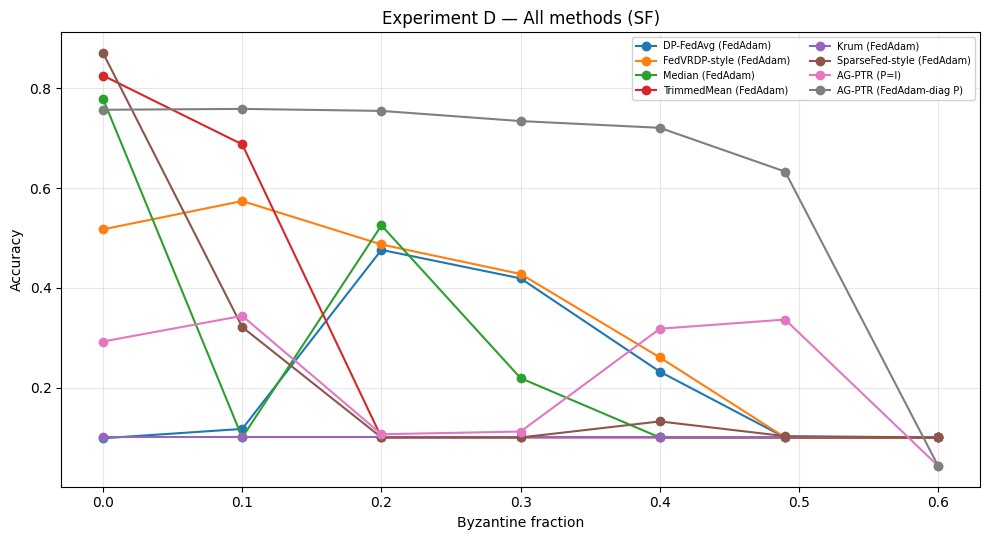

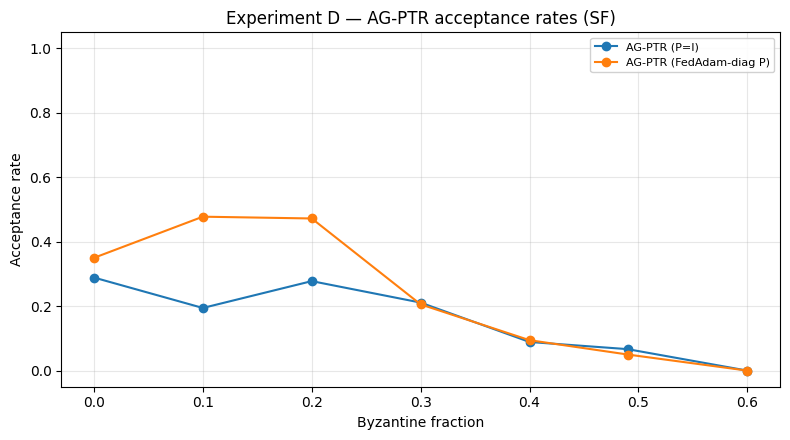


==================== Smoke Attack: MinMax ====================
Saved expD_allmethods_smoke_minmax.csv


,attack,method,f,acc,accept_rate
0,MinMax,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,MinMax,DP-FedAvg (FedAdam),0.10,0.1019,NaN
2,MinMax,DP-FedAvg (FedAdam),0.20,0.0878,NaN
3,MinMax,DP-FedAvg (FedAdam),0.30,0.4082,NaN
4,MinMax,DP-FedAvg (FedAdam),0.40,0.3786,NaN
5,MinMax,DP-FedAvg (FedAdam),0.49,0.2320,NaN
6,MinMax,DP-FedAvg (FedAdam),0.60,0.1501,NaN
7,MinMax,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,MinMax,FedVRDP-style (FedAdam),0.10,0.5956,NaN
9,MinMax,FedVRDP-style (FedAdam),0.20,0.5222,NaN


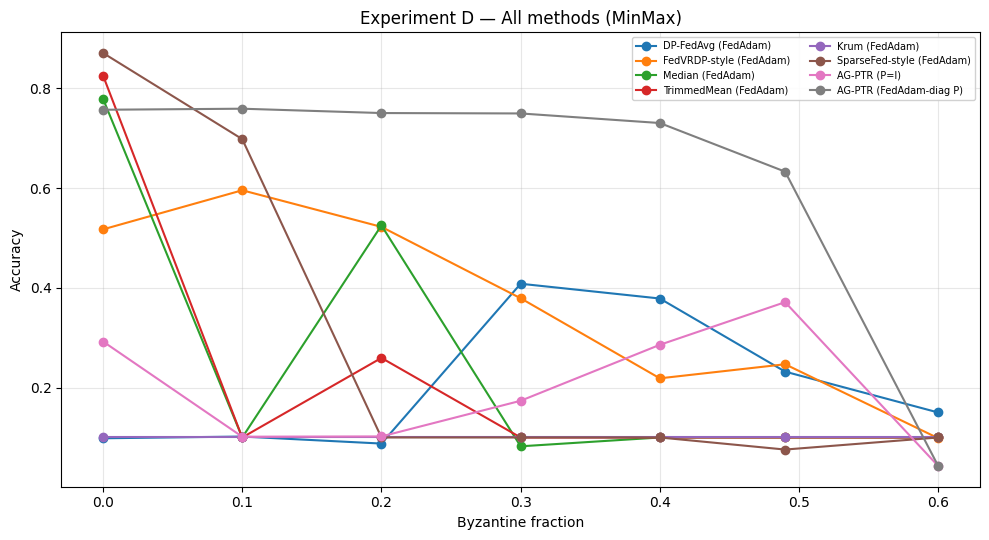

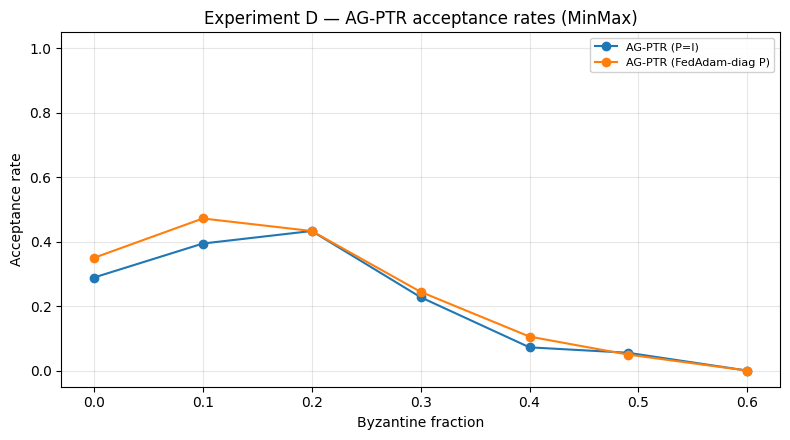


==================== Smoke Attack: MinSum ====================
Saved expD_allmethods_smoke_minsum.csv


,attack,method,f,acc,accept_rate
0,MinSum,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,MinSum,DP-FedAvg (FedAdam),0.10,0.1023,NaN
2,MinSum,DP-FedAvg (FedAdam),0.20,0.0970,NaN
3,MinSum,DP-FedAvg (FedAdam),0.30,0.4045,NaN
4,MinSum,DP-FedAvg (FedAdam),0.40,0.2937,NaN
5,MinSum,DP-FedAvg (FedAdam),0.49,0.3044,NaN
6,MinSum,DP-FedAvg (FedAdam),0.60,0.1170,NaN
7,MinSum,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,MinSum,FedVRDP-style (FedAdam),0.10,0.5913,NaN
9,MinSum,FedVRDP-style (FedAdam),0.20,0.4895,NaN


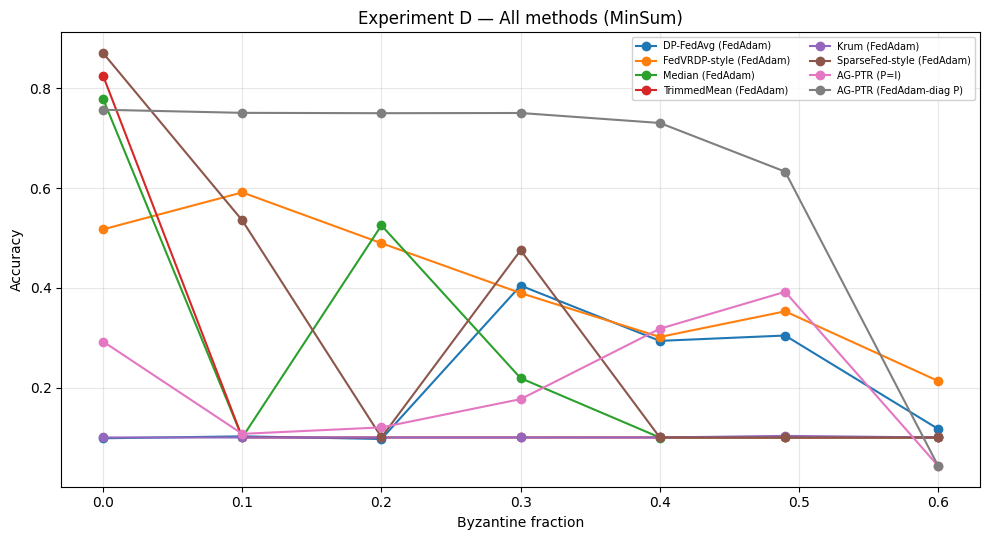

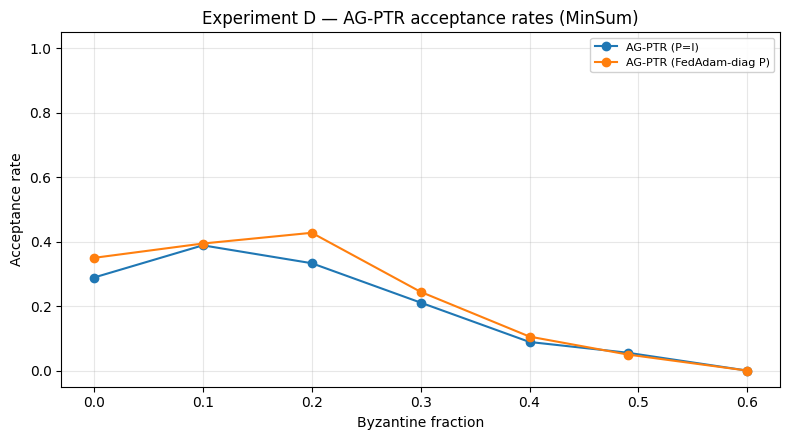


==================== Smoke Attack: LF ====================
Saved expD_allmethods_smoke_lf.csv


,attack,method,f,acc,accept_rate
0,LF,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,LF,DP-FedAvg (FedAdam),0.10,0.0993,NaN
2,LF,DP-FedAvg (FedAdam),0.20,0.1012,NaN
3,LF,DP-FedAvg (FedAdam),0.30,0.0995,NaN
4,LF,DP-FedAvg (FedAdam),0.40,0.0983,NaN
5,LF,DP-FedAvg (FedAdam),0.49,0.0975,NaN
6,LF,DP-FedAvg (FedAdam),0.60,0.0969,NaN
7,LF,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,LF,FedVRDP-style (FedAdam),0.10,0.4437,NaN
9,LF,FedVRDP-style (FedAdam),0.20,0.3888,NaN


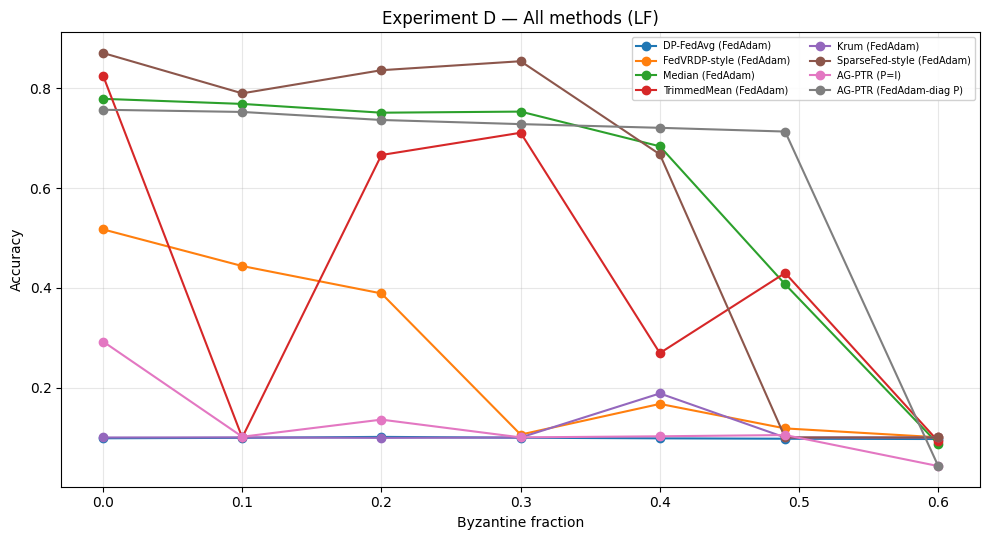

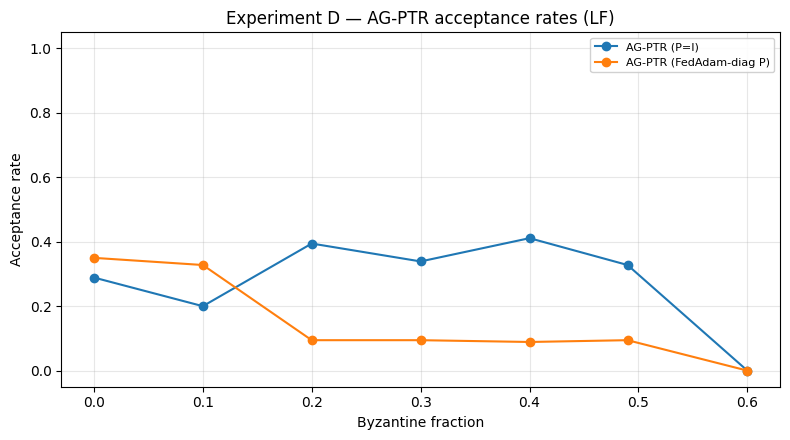


==================== Smoke Attack: FoE ====================
Saved expD_allmethods_smoke_foe.csv


,attack,method,f,acc,accept_rate
0,FoE,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,FoE,DP-FedAvg (FedAdam),0.10,0.0965,NaN
2,FoE,DP-FedAvg (FedAdam),0.20,0.3975,NaN
3,FoE,DP-FedAvg (FedAdam),0.30,0.2913,NaN
4,FoE,DP-FedAvg (FedAdam),0.40,0.1911,NaN
5,FoE,DP-FedAvg (FedAdam),0.49,0.1000,NaN
6,FoE,DP-FedAvg (FedAdam),0.60,0.1000,NaN
7,FoE,FedVRDP-style (FedAdam),0.00,0.5172,NaN
8,FoE,FedVRDP-style (FedAdam),0.10,0.6134,NaN
9,FoE,FedVRDP-style (FedAdam),0.20,0.5787,NaN


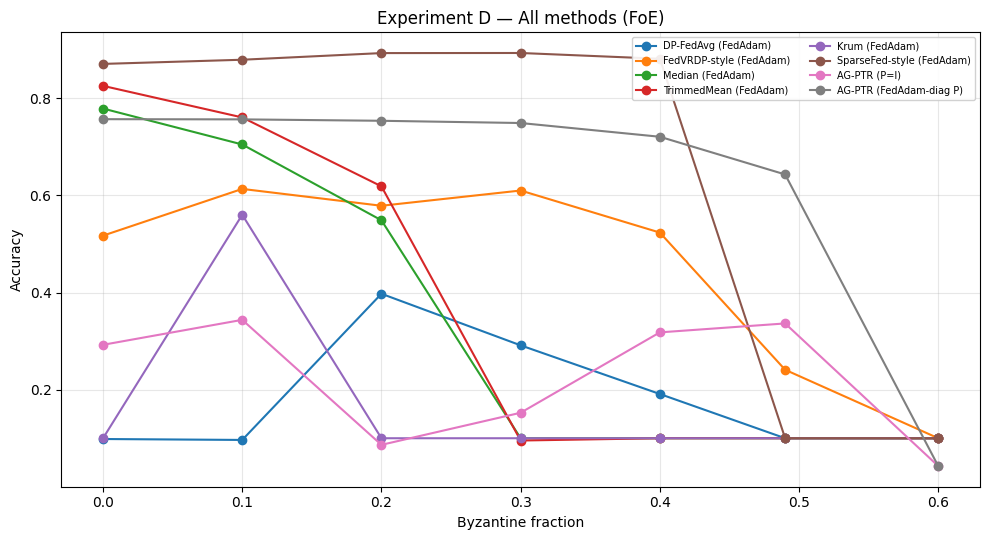

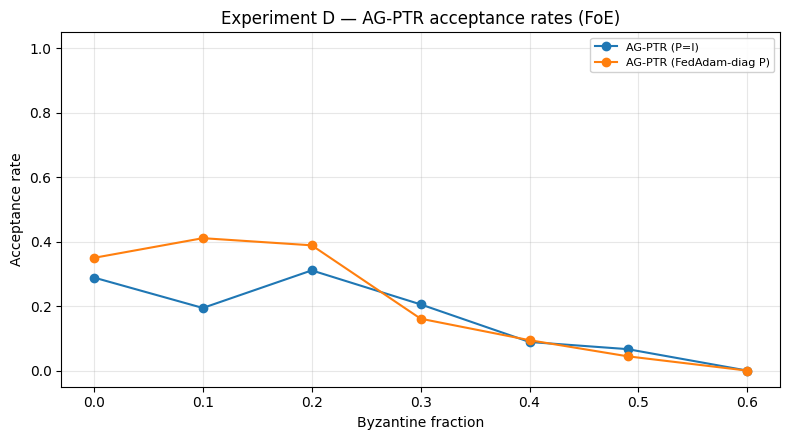

Saved expD_allmethods_Full_all_results.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg (FedAdam),0.00,0.0984,NaN
1,ALIE,DP-FedAvg (FedAdam),0.10,0.1023,NaN
2,ALIE,DP-FedAvg (FedAdam),0.20,0.1026,NaN
3,ALIE,DP-FedAvg (FedAdam),0.30,0.1273,NaN
4,ALIE,DP-FedAvg (FedAdam),0.40,0.1013,NaN
...,...,...,...,...,...
331,SF,AG-PTR (FedAdam-diag P),0.20,0.7547,0.472222
332,SF,AG-PTR (FedAdam-diag P),0.30,0.7343,0.205556
333,SF,AG-PTR (FedAdam-diag P),0.40,0.7208,0.094444
334,SF,AG-PTR (FedAdam-diag P),0.49,0.6330,0.050000


In [20]:
# Cell 16 — Full Run

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 180
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

# Attack params
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1

# AG-PTR params
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2

# DP-FedAvg / FedVRDP-style params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30

# SparseFed-style params
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

# Shared FedAdam server params for baselines
BASELINE_SERVER_OPT = "fedadam"
ADAM_ETA = 0.1
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.99
ADAM_TAU = 1e-9
ADAM_V_INIT = 1e-6

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

AG_VARIANTS = [
    ("AG-PTR (P=I)", "identity"),
    ("AG-PTR (FedAdam-diag P)", "fedadam_diag"),
]

METHOD_ORDER = [
    "DP-FedAvg (FedAdam)",
    "FedVRDP-style (FedAdam)",
    "Median (FedAdam)",
    "TrimmedMean (FedAdam)",
    "Krum (FedAdam)",
    "SparseFed-style (FedAdam)",
    "AG-PTR (P=I)",
    "AG-PTR (FedAdam-diag P)",
]

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_dp = epsilon_from_sigma_single(sigma_dp, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("sigma_dp:", sigma_dp, "achieved eps≈", eps_dp)
print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"Baseline server optimizer: {BASELINE_SERVER_OPT}")
print(f"FedAdam params: eta={ADAM_ETA}, beta1={ADAM_BETA1}, beta2={ADAM_BETA2}, tau={ADAM_TAU}, v_init={ADAM_V_INIT}")

all_rows = []

for attack_name, attack_key in ATTACKS:
    print(f"\n==================== Smoke Attack: {attack_name} ====================")
    attack_rows = []

    for f in f_list:
        acc_dp, _ = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_vr, _ = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC_VR,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_med, _ = train_median_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_tmean, _ = train_trimmedmean_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            trim_k=None,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_krum, _ = train_krum_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        acc_sparse, _ = train_sparsefed_style_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False,
            server_opt=BASELINE_SERVER_OPT,
            adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
            adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT
        )

        attack_rows.extend([
            {"attack": attack_name, "method": "DP-FedAvg (FedAdam)",       "f": f, "acc": acc_dp,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "FedVRDP-style (FedAdam)",   "f": f, "acc": acc_vr,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "Median (FedAdam)",          "f": f, "acc": acc_med,    "accept_rate": np.nan},
            {"attack": attack_name, "method": "TrimmedMean (FedAdam)",     "f": f, "acc": acc_tmean,  "accept_rate": np.nan},
            {"attack": attack_name, "method": "Krum (FedAdam)",            "f": f, "acc": acc_krum,   "accept_rate": np.nan},
            {"attack": attack_name, "method": "SparseFed-style (FedAdam)", "f": f, "acc": acc_sparse, "accept_rate": np.nan},
        ])

        for ag_name, p_mode in AG_VARIANTS:
            acc_ag, ar_ag = train_ag_ptr_geom(
                seed, eps_total, f,
                sigma_sel, sigma_rel, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                rho=RHO, tau=TAU,
                R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                attack_type=attack_key,
                alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                label_flip_shift=LABEL_FLIP_SHIFT,
                allow_zero=False,
                P_mode=p_mode,
                adam_eta=ADAM_ETA, adam_beta1=ADAM_BETA1,
                adam_beta2=ADAM_BETA2, adam_tau=ADAM_TAU, adam_v_init=ADAM_V_INIT,
                show_progress=False
            )

            attack_rows.append({
                "attack": attack_name,
                "method": ag_name,
                "f": f,
                "acc": acc_ag,
                "accept_rate": ar_ag
            })

    df_attack = pd.DataFrame(attack_rows)
    df_attack["method"] = pd.Categorical(df_attack["method"], categories=METHOD_ORDER, ordered=True)
    df_attack = df_attack.sort_values(["method", "f"]).reset_index(drop=True)

    df_attack.to_csv(f"expD_allmethods_smoke_{attack_key}.csv", index=False)
    print(f"Saved expD_allmethods_smoke_{attack_key}.csv")
    display(df_attack)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for method in METHOD_ORDER:
        sub = df_attack[df_attack["method"] == method]
        ax.plot(sub["f"], sub["acc"], marker="o", label=method)
    ax.set_xlabel("Byzantine fraction")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Experiment D — All methods ({attack_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9, ncol=2)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    sub = df_attack[df_attack["method"].isin(["AG-PTR (P=I)", "AG-PTR (FedAdam-diag P)"])]
    for method in ["AG-PTR (P=I)", "AG-PTR (FedAdam-diag P)"]:
        ss = sub[sub["method"] == method]
        ax.plot(ss["f"], ss["accept_rate"], marker="o", label=method)
    ax.set_xlabel("Byzantine fraction")
    ax.set_ylabel("Acceptance rate")
    ax.set_title(f"Experiment D — AG-PTR acceptance rates ({attack_name})")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
    fig.tight_layout()
    plt.show()

    all_rows.extend(attack_rows)

df_smoke_all = pd.DataFrame(all_rows)
df_smoke_all["method"] = pd.Categorical(df_smoke_all["method"], categories=METHOD_ORDER, ordered=True)
df_smoke_all = df_smoke_all.sort_values(["attack", "method", "f"]).reset_index(drop=True)

df_smoke_all.to_csv("expD_allmethods_smoke_all_results.csv", index=False)
print("Saved expD_allmethods_Full_all_results.csv")
display(df_smoke_all)